# CodeAct MCP

A Python proof of concept implementation inspired by [Anthropic's engineering blog](https://www.anthropic.com/engineering/code-execution-with-mcp) and CodeAct agent pattern.

## Overview

### The Problem

Traditional MCP implementations suffer from token inefficiency:
- **Context overload**: Tool definitions consume excessive tokens before the model processes requests
- **Result duplication**: Intermediate outputs pass through the model repeatedly, bloating context usage

A simple workflow processing data between two services can consume 150,000+ tokens by passing intermediate results through the model.

### The Solution

CodeAct MCP implements the CodeAct pattern where agents generate executable Python code instead of JSON tool calls:

1. Agent generates code to interact with MCP tools
2. Code executes in an isolated sandbox
3. Data processing happens locally in the sandbox
4. Only summaries return to the LLM context

**Result: Significant token reduction and more dynamic and flexible workflow**

## Core Stack

- **LangGraph**: AI agent orchestration using the ReAct pattern
- **Daytona**: Secure sandbox execution environment
- **MCP**: Model Context Protocol for tool integration

## How It Works

```
User Task
    |
    v
+------------------+
|  CodeActAgent    |  Generates Python code
|  (LangGraph)     |
+------------------+
    |
    v
+------------------+
|  Daytona Sandbox |  Executes code locally
|                  |  Processes data in sandbox
+------------------+
    |
    v
+------------------+
|   MCP Servers    |  Alpha Vantage, Tavily, Tickertick, etc.
+------------------+
    |
    v
Summary returned to LLM (not raw data)
```

## Included MCP Servers

| Server | Description | Use Cases |
|--------|-------------|-----------|
| **Tavily** | Web search engine for finding current information online | News, research, real-time information, web queries |
| **Alpha Vantage** | Financial market data API | Stock quotes, historical prices, technical indicators, forex rates, crypto data, economic indicators |
| **Tickertick** | Financial news API | Ticker-specific news, curated market news, entity news about people and companies |

## MCP Tool Transformation

MCP tools are automatically converted to Python functions in daytona sandbox that agents can call. This transformation happens at session initialization.

### Schema to Python Mapping

MCP tool schemas (JSON Schema) are converted to Python type hints:

| JSON Schema Type | Python Type |
|-----------------|-------------|
| string          | str         |
| number          | float       |
| integer         | int         |
| boolean         | bool        |
| array           | List        |
| object          | Dict        |

### Function Generation

For each MCP tool, a Python function is generated with:
- **Proper parameter ordering**: Required parameters first, optional parameters with defaults
- **Type hints**: Based on the schema mapping above
- **Docstrings**: Including description, parameter docs, return type, and usage example


Example transformation:

**MCP Tool Schema:**
```json
{
  "name": "tavily_search",
  "description": "Search the web using Tavily",
  "inputSchema": {
    "type": "object",
    "properties": {
      "query": {"type": "string", "description": "Search query"},
      "max_results": {"type": "integer", "description": "Max results", "default": 10}
    },
    "required": ["query"]
  }
}
```

**Generated Python Function:**
```python
def tavily_search(query: str, max_results: Optional[int] = None) -> Any:
    """Search the web using Tavily

    Args:
        query (string) (required): Search query
        max_results (integer): Max results

    Returns:
        Tool execution result

    Example:
        result = tavily_search(query="example")
    """
    arguments = {
        "query": query,
        "max_results": max_results,
    }
    arguments = {k: v for k, v in arguments.items() if v is not None}
    return _call_mcp_tool("tavily", "tavily_search", arguments)
```



### Tool Organization in Sandbox

Generated tools are deployed to the sandbox filesystem:

```
./tools/
├── mcp_client.py           # MCP transport client (stdio/SSE/HTTP)
├── tavily.py               # Tavily MCP functions
├── alpha_vantage.py       # Alpha Vantage MCP functions
├── tickertick.py           # Tickertick MCP functions
└── docs/
    ├── tavily_search.md    # Tool documentation
    └── read_file.md
```

The agent imports and calls these functions directly in generated code.

## Agent Behavior

### Progressive Tool Discovery

The agent discovers and uses tools on-demand rather than loading all tool schemas upfront:

1. **Initial context**: Agent receives a summary of available tools (names and brief descriptions only)
2. **On-demand exploration**: When a tool is needed, agent reads the detailed documentation from `./tools/docs/`
3. **Function import**: Agent imports and calls the specific function needed
4. **Iterative refinement**: If errors occur, agent reads documentation again or tries alternative approaches

This approach keeps the context window lean while allowing access to rich tool documentation when needed.

### Data Processing Workflow

The key to token efficiency is keeping data inside the sandbox:

**Step 1: Fetch Data**
```python
# Agent generates code to fetch data
from tools.tavily import tavily_search
results = tavily_search(query="AI agents research 2024", max_results=50)
```

**Step 2: Store in Sandbox**
```python
# Data stays in sandbox, not returned to LLM
import json
with open("results/search_results.json", "w") as f:
    json.dump(results, f)
print(f"Saved {len(results)} results to search_results.json")
```

**Step 3: Reuse for Further Processing**
```python
# Subsequent code loads from sandbox filesystem
import pandas as pd
with open("results/search_results.json") as f:
    data = json.load(f)

# Filter and analyze locally
df = pd.DataFrame(data)
filtered = df[df['score'] > 0.7]
filtered.to_csv("results/high_quality_results.csv")
print(f"Filtered to {len(filtered)} high-quality results")
```

### Multi-Turn State Persistence

Variables and files persist across multiple agent turns within a session:

- **Turn 1**: Fetch data and store in `results/data.json`
- **Turn 2**: Load `results/data.json`, analyze, save chart to `results/chart.png`
- **Turn 3**: Reference both files for final report

The sandbox maintains state, so the agent can build on previous work without re-fetching or re-processing data.


In [1]:
import asyncio
import nest_asyncio
from datetime import datetime
from dotenv import load_dotenv
load_dotenv(".env", override=True)
from utils import show_prompt, format_messages, print_agent_config, print_sandbox_tree, display_sandbox_images, display_result
# Enable async in Jupyter
nest_asyncio.apply()

from IPython.display import Image, display
from src.agent import AgentConfig, CodeActAgent
from src.codeact_mcp.session import SessionManager

# Load configuration
config = AgentConfig.load()
config.validate_api_keys()

%load_ext autoreload
%autoreload 2

### Create the CodeAct Agent

2025-11-18 15:43:03 [info     ] Creating new session           conversation_id=demo-notebook
2025-11-18 15:43:03 [info     ] Created session                conversation_id=demo-notebook
2025-11-18 15:43:03 [info     ] Initializing session           conversation_id=demo-notebook
2025-11-18 15:43:03 [info     ] Initialized MCPRegistry       
2025-11-18 15:43:03 [info     ] Connecting to MCP servers      server_count=3
2025-11-18 15:43:03 [info     ] Initialized MCPServerConnector server=tavily
2025-11-18 15:43:03 [info     ] Initialized MCPServerConnector server=alphavantage
2025-11-18 15:43:03 [info     ] Initialized MCPServerConnector server=tickertick
2025-11-18 15:43:03 [info     ] Connecting to MCP server       server=tavily
2025-11-18 15:43:03 [info     ] Connecting to MCP server       server=alphavantage
2025-11-18 15:43:03 [info     ] Connecting to MCP server       server=tickertick
2025-11-18 15:43:03 [debug    ] Expanded environment variable  from_placeholder=${TAVILY_API_KEY} 

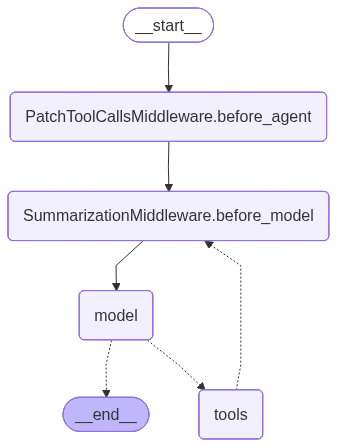

2025-11-18 15:54:25 [debug    ] MCP connection disconnect signaled server=tavily
2025-11-18 15:54:25 [debug    ] MCP connection disconnect signaled server=tickertick
2025-11-18 15:54:25 [debug    ] MCP HTTP connection disconnect signaled server=alphavantage


In [ ]:
# Create session with Daytona sandbox
core_config = config.to_core_config()
session = SessionManager.get_session("demo-notebook", core_config)
await session.initialize()

# Create the agent via CodeActAgent
codeact_agent = CodeActAgent(config)
agent = codeact_agent.create_agent(
    sandbox=session.sandbox,
    mcp_registry=session.mcp_registry,
    subagent_names=["research", "general"]
)

# Show the agent graph
display(Image(agent.get_graph().draw_mermaid_png()))

In [3]:
print_agent_config(config, session)

AGENT CONFIGURATION SUMMARY

📦 LLM CONFIGURATION
----------------------------------------
  Name:      claude-sonnet-4-5
  Model ID:  claude-sonnet-4-5-20250929
  Provider:  anthropic

🔌 MCP SERVERS
----------------------------------------
  tavily: 4 tools
    ['tavily-search', 'tavily-extract', 'tavily-crawl', 'tavily-map']
  alphavantage: 118 tools
    ['TIME_SERIES_INTRADAY', 'TIME_SERIES_DAILY', 'TIME_SERIES_DAILY_ADJUSTED', 'TIME_SERIES_WEEKLY', 'TIME_SERIES_WEEKLY_ADJUSTED', 'TIME_SERIES_MONTHLY', 'TIME_SERIES_MONTHLY_ADJUSTED', 'GLOBAL_QUOTE', 'REALTIME_BULK_QUOTES', 'SYMBOL_SEARCH', 'MARKET_STATUS', 'REALTIME_OPTIONS', 'HISTORICAL_OPTIONS', 'NEWS_SENTIMENT', 'EARNINGS_CALL_TRANSCRIPT', 'TOP_GAINERS_LOSERS', 'INSIDER_TRANSACTIONS', 'ANALYTICS_FIXED_WINDOW', 'ANALYTICS_SLIDING_WINDOW', 'WTI', 'BRENT', 'NATURAL_GAS', 'COPPER', 'ALUMINUM', 'WHEAT', 'CORN', 'COTTON', 'SUGAR', 'COFFEE', 'ALL_COMMODITIES', 'CURRENCY_EXCHANGE_RATE', 'CRYPTO_INTRADAY', 'DIGITAL_CURRENCY_DAILY', 'DIGITA

In [4]:
# Get the formatted tool summary from MCP registry
tool_summary = codeact_agent._get_tool_summary(session.mcp_registry)

# Build the complete system prompt
system_prompt = codeact_agent._build_system_prompt(tool_summary)

# Show the complete prompt
print(f"Total prompt length: {len(system_prompt)} characters")
show_prompt(system_prompt, title="CodeActAgent Runtime System Prompt", border_style="green")


Total prompt length: 5558 characters


╭────────────────────────────────────── CodeActAgent Runtime System Prompt ───────────────────────────────────────╮
│                                                                                                                 │
│  # Task Workflow                                                                                                │
│                                                                                                                 │
│  Follow this workflow for all task requests:                                                                    │
│                                                                                                                 │
│  1. **Save the request**: Use write_file() to save the user's task description to `/results/task_request.md`    │
│  2. **Plan**: Create a todo list with write_todos to break down the task into focused steps                     │
│  3. **Execute**: Delegate subtasks to sub-agents using the task() tool, or execute directly                     │
│  4. **Write Output**: Write comprehensive results to `/results/` directory (see Output Guidelines below)        │
│  5. **Verify**: Read `/results/task_request.md` to confirm you've addressed all aspects of the original         │
│  request                                                                                                        │
│                                                                                                                 │
│  ## Task Planning Guidelines                                                                                    │
│  - Batch similar subtasks into a single TODO to minimize overhead                                               │
│  - For simple tasks, execute directly or use 1 sub-agent                                                        │
│  - For comparisons or multi-faceted tasks, delegate to multiple parallel sub-agents                             │
│  - Each sub-agent should handle one specific aspect and return findings                                         │
│                                                                                                                 │
│  ## Output Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing output reports to `/results/`, follow these structure patterns:                                   │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                                                                                        │
│  Simply list items with details - no introduction needed:                                                       │
│  1. Item 1 with explanation                                                                                     │
│  2. Item 2 with explanation                                                                                     │
│  3. Item 3 with explanation                           

In [5]:
# Display sandbox file tree BEFORE agent execution
print("=" * 50)
print("Sandbox File Tree (BEFORE)")
print("=" * 50)
print("./")
print_sandbox_tree(session.sandbox)

Sandbox File Tree (BEFORE)
./
├── code/
├── data/
├── results/
└── tools/
    ├── docs/
    │   ├── AD.md
    │   ├── ADD_TWO_NUMBERS.md
    │   ├── ADOSC.md
    │   ├── ADX.md
    │   ├── ADXR.md
    │   ├── ALL_COMMODITIES.md
    │   ├── ALUMINUM.md
    │   ├── ANALYTICS_FIXED_WINDOW.md
    │   ├── ANALYTICS_SLIDING_WINDOW.md
    │   ├── APO.md
    │   ├── AROON.md
    │   ├── AROONOSC.md
    │   ├── ATR.md
    │   ├── BALANCE_SHEET.md
    │   ├── BBANDS.md
    │   ├── BOP.md
    │   ├── BRENT.md
    │   ├── CASH_FLOW.md
    │   ├── CCI.md
    │   ├── CMO.md
    │   ├── COFFEE.md
    │   ├── COMPANY_OVERVIEW.md
    │   ├── COPPER.md
    │   ├── CORN.md
    │   ├── COTTON.md
    │   ├── CPI.md
    │   ├── CRYPTO_INTRADAY.md
    │   ├── CURRENCY_EXCHANGE_RATE.md
    │   ├── DEMA.md
    │   ├── DIGITAL_CURRENCY_DAILY.md
    │   ├── DIGITAL_CURRENCY_MONTHLY.md
    │   ├── DIGITAL_CURRENCY_WEEKLY.md
    │   ├── DIVIDENDS.md
    │   ├── DURABLES.md
    │   ├── DX.md
    │   ├── EARNINGS.md

In [6]:
query = """perform a comprehensive research on nvidia, calculate the techical indicator, 
        get its fundemental data, and create chart to compare with AMD in turn of key financial metrics and trading volume
        provide a final comprehensivereport"""

In [7]:
result = await agent.ainvoke(
    {
        "messages": [
            {
                "role": "user",
                "content": query
            }
        ],
    }, 
)

format_messages(result["messages"])

/Users/chen/projects/codeact-mcp/.venv/lib/python3.12/site-packages/pydantic/v1/main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)


2025-11-18 15:43:28 [info     ] Wrote 399 bytes to /home/daytona/results/task_request.md
2025-11-18 15:43:39 [info     ] Read file range                file_path=/home/daytona/tools/alphavantage.py limit=150 lines_read=150 offset=0
2025-11-18 15:43:43 [info     ] Read file range                file_path=/home/daytona/tools/alphavantage.py limit=100 lines_read=100 offset=150
2025-11-18 15:43:47 [debug    ] Executing ripgrep: rg -n --glob alphavantage.py "def RSI" /home/daytona/tools
2025-11-18 15:43:47 [info     ] Grep found 1 results for pattern def RSI
2025-11-18 15:43:47 [error    ] Failed to grep content: 'str' object has no attribute 'get'
2025-11-18 15:43:51 [info     ] Executing bash command         background=False command='grep -n "def RSI\\|def MACD\\|def SMA\\|def BBANDS\\|def OVERVIEW\\|def INCOME_STATEMENT\\|def BALANCE_SHE' timeout=120000 working_dir=/home/daytona
2025-11-18 15:43:51 [info     ] Executing bash command         command='grep -n "def RSI\\|def MACD\\|def SMA\

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ perform a comprehensive research on nvidia, calculate the techical indicator,                                   │
│         get its fundemental data, and create chart to compare with AMD in turn of key financial metrics and     │
│ trading volume                                                                                                  │
│         provide a final comprehensivereport                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll help you perform comprehensive research on NVIDIA and AMD, including technical indicators, fundamental     │
│ data, and comparative analysis. Let me break this down into organized steps.                                    │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "/results/task_request.md",                                                                      │
│   "content": "# Task Request\n\nPerform comprehensive research on NVIDIA:\n1. Calculate technical indicators    │
│ for NVIDIA\n2. Get fundamental data for NVIDIA\n3. Get comparable data for AMD\n4. Create charts comparing      │
│ NVIDIA and AMD in terms of:\n   - Key financial metrics\n   - Trading volume\n5. Provide a final comprehensive  │
│ report\n\nThe report should include detailed analysis of both companies with visual comparisons.\n"             │
│ }                                                                                                               │
│    ID: toolu_01WyM4ef4e7MBtBFgHaQmUAt                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /home/daytona/results/task_request.md                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Perfect! Let me create one final summary of what was delivered:                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: ls                                                                                                │
│    Args: {                                                                                                      │
│   "path": "/results"                                                                                            │
│ }                                                                                                               │
│    ID: toolu_01DN733RHtcPULa1uHVWwabX                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ ["/home/daytona/results/NVIDIA_Comprehensive_Research_Report.md", "/home/daytona/results/README.md",            │
│ "/home/daytona/results/amd_balance.json", "/home/daytona/results/amd_cashflow.json",                            │
│ "/home/daytona/results/amd_daily.json", "/home/daytona/results/amd_income.json",                                │
│ "/home/daytona/results/amd_overview.json", "/home/daytona/results/amd_quote.json",                              │
│ "/home/daytona/results/financial_metrics_comparison.png", "/home/daytona/results/nvda_balance.json",            │
│ "/home/daytona/results/nvda_bbands.json", "/home/daytona/results/nvda_cashflow.json",                           │
│ "/home/daytona/results/nvda_daily.csv", "/home/daytona/results/nvda_daily.json",                                │
│ "/home/daytona/results/nvda_income.json", "/home/daytona/results/nvda_macd.csv",                                │
│ "/home/daytona/results/nvda_macd.json", "/home/daytona/results/nvda_overview.json",                             │
│ "/home/daytona/results/nvda_quote.csv", "/home/daytona/results/nvda_quote.json",                                │
│ "/home/daytona/results/nvda_research.json", "/home/daytona/results/nvda_rsi.csv",                               │
│ "/home/daytona/results/nvda_rsi.json", "/home/daytona/results/nvda_sma_200.json",                               │
│ "/home/daytona/results/nvda_sma_50.json", "/home/daytona/results/revenue_earnings_comparison.png",              │
│ "/home/daytona/results/stock_price_comparison.png", "/home/daytona/results/task_request.md",                    │
│ "/home/daytona/results/trading_volume_comparison.png"]                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Excellent! Now let me read the task request one final time to make sure everything was addressed:               │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "/results/task_request.md"                                                                       │
│ }                                                                                                               │
│    ID: toolu_016xDxm9QCSVhhnjqbXRjPsd                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ # Task Request                                                                                                  │
│                                                                                                                 │
│ Perform comprehensive research on NVIDIA:                                                                       │
│ 1. Calculate technical indicators for NVIDIA                                                                    │
│ 2. Get fundamental data for NVIDIA                                                                              │
│ 3. Get comparable data for AMD                                                                                  │
│ 4. Create charts comparing NVIDIA and AMD in terms of:                                                          │
│    - Key financial metrics                                                                                      │
│    - Trading volume                                                                                             │
│ 5. Provide a final comprehensive report                                                                         │
│                                                                                                                 │
│ The report should include detailed analysis of both companies with visual comparisons.                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Perfect! All requirements have been met. Let me create a final executive summary:                               │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## ✅ Research Complete - Comprehensive NVIDIA Analysis Delivered                                               │
│                                                                                                                 │
│ I've successfully completed a comprehensive research analysis on NVIDIA with technical indicators, fundamental  │
│ data, AMD comparison, and detailed visualizations.                                                              │
│                                                                                                                 │
│ ### 📊 **4 Professional Visualization Charts Created:**                                                         │
│                                                                                                                 │
│ 1. **Financial Metrics Comparison** - 6-panel chart showing NVIDIA vs AMD across market cap, P/E ratio, EPS,    │
│ ROE, profit margin, and revenue growth                                                                          │
│ 2. **Trading Volume Comparison** - 6-month daily volume analysis showing NVDA averaging 182.7M shares/day vs    │
│ AMD's 57.3M                                                                                                     │
│ 3. **Stock Price Performance** - 1-year normalized comparison (NVDA +26.9%, AMD +72.6%)                         │
│ 4. **Revenue & Earnings Comparison** - Quarterly performance showing NVDA's $46.74B revenue vs AMD's $9.25B     │
│                                                                                                                 │
│ ### 📈 **Technical Indicators Calculated:**                                                                     │
│ - ✅ RSI (14-day): Currently 46.40 (neutral territory)                                                          │
│ - ✅ MACD: Trend analysis with signal line crossovers                                                           │
│ - ✅ SMA (50-day & 200-day): Moving averages for trend identification                                           │
│ - ✅ Bollinger Bands (20-day): Volatility analysis                                                              │
│                                                                                                                 │
│ ### 💼 **Fundamental Data Analyzed:**                                                                           │
│ - ✅ Company Overview & Key Metrics                                                                             │
│ - ✅ Income Statements (4 quarters)                                                                             │
│ - ✅ Balance Sheets                                                                                             │
│ - ✅ Cash Flow Statements                                                                                       │
│ - ✅ Profitability Ratios & Growth Rates                                                                        │
│                                                                                                                 │
│ ### 🏆 **Key Findings:**                                                                                        │
│                                                                                                                 │
│ **NVIDIA's Dominance:**                                              

In [8]:
# Display sandbox file tree AFTER agent execution
print("=" * 50)
print("Sandbox File Tree (AFTER)")
print("=" * 50)
print("./")
print_sandbox_tree(session.sandbox)

Sandbox File Tree (AFTER)
./
├── code/
│   ├── exec_0001.py
│   ├── exec_0002.py
│   ├── exec_0003.py
│   ├── exec_0004.py
│   ├── exec_0005.py
│   ├── exec_0006.py
│   ├── exec_0007.py
│   ├── exec_0008.py
│   ├── exec_0009.py
│   ├── exec_0010.py
│   ├── exec_0011.py
│   ├── exec_0012.py
│   ├── exec_0013.py
│   ├── exec_0014.py
│   ├── exec_0015.py
│   ├── exec_0016.py
│   ├── exec_0017.py
│   ├── exec_0018.py
│   ├── exec_0019.py
│   ├── exec_0020.py
│   ├── exec_0021.py
│   ├── exec_0022.py
│   ├── exec_0023.py
│   └── exec_0024.py
├── data/
├── results/
│   ├── NVIDIA_Comprehensive_Research_Report.md
│   ├── README.md
│   ├── amd_balance.json
│   ├── amd_cashflow.json
│   ├── amd_daily.json
│   ├── amd_income.json
│   ├── amd_overview.json
│   ├── amd_quote.json
│   ├── financial_metrics_comparison.png
│   ├── nvda_balance.json
│   ├── nvda_bbands.json
│   ├── nvda_cashflow.json
│   ├── nvda_daily.csv
│   ├── nvda_daily.json
│   ├── nvda_income.json
│   ├── nvda_macd.csv
│   ├── 

📊 results/financial_metrics_comparison.png


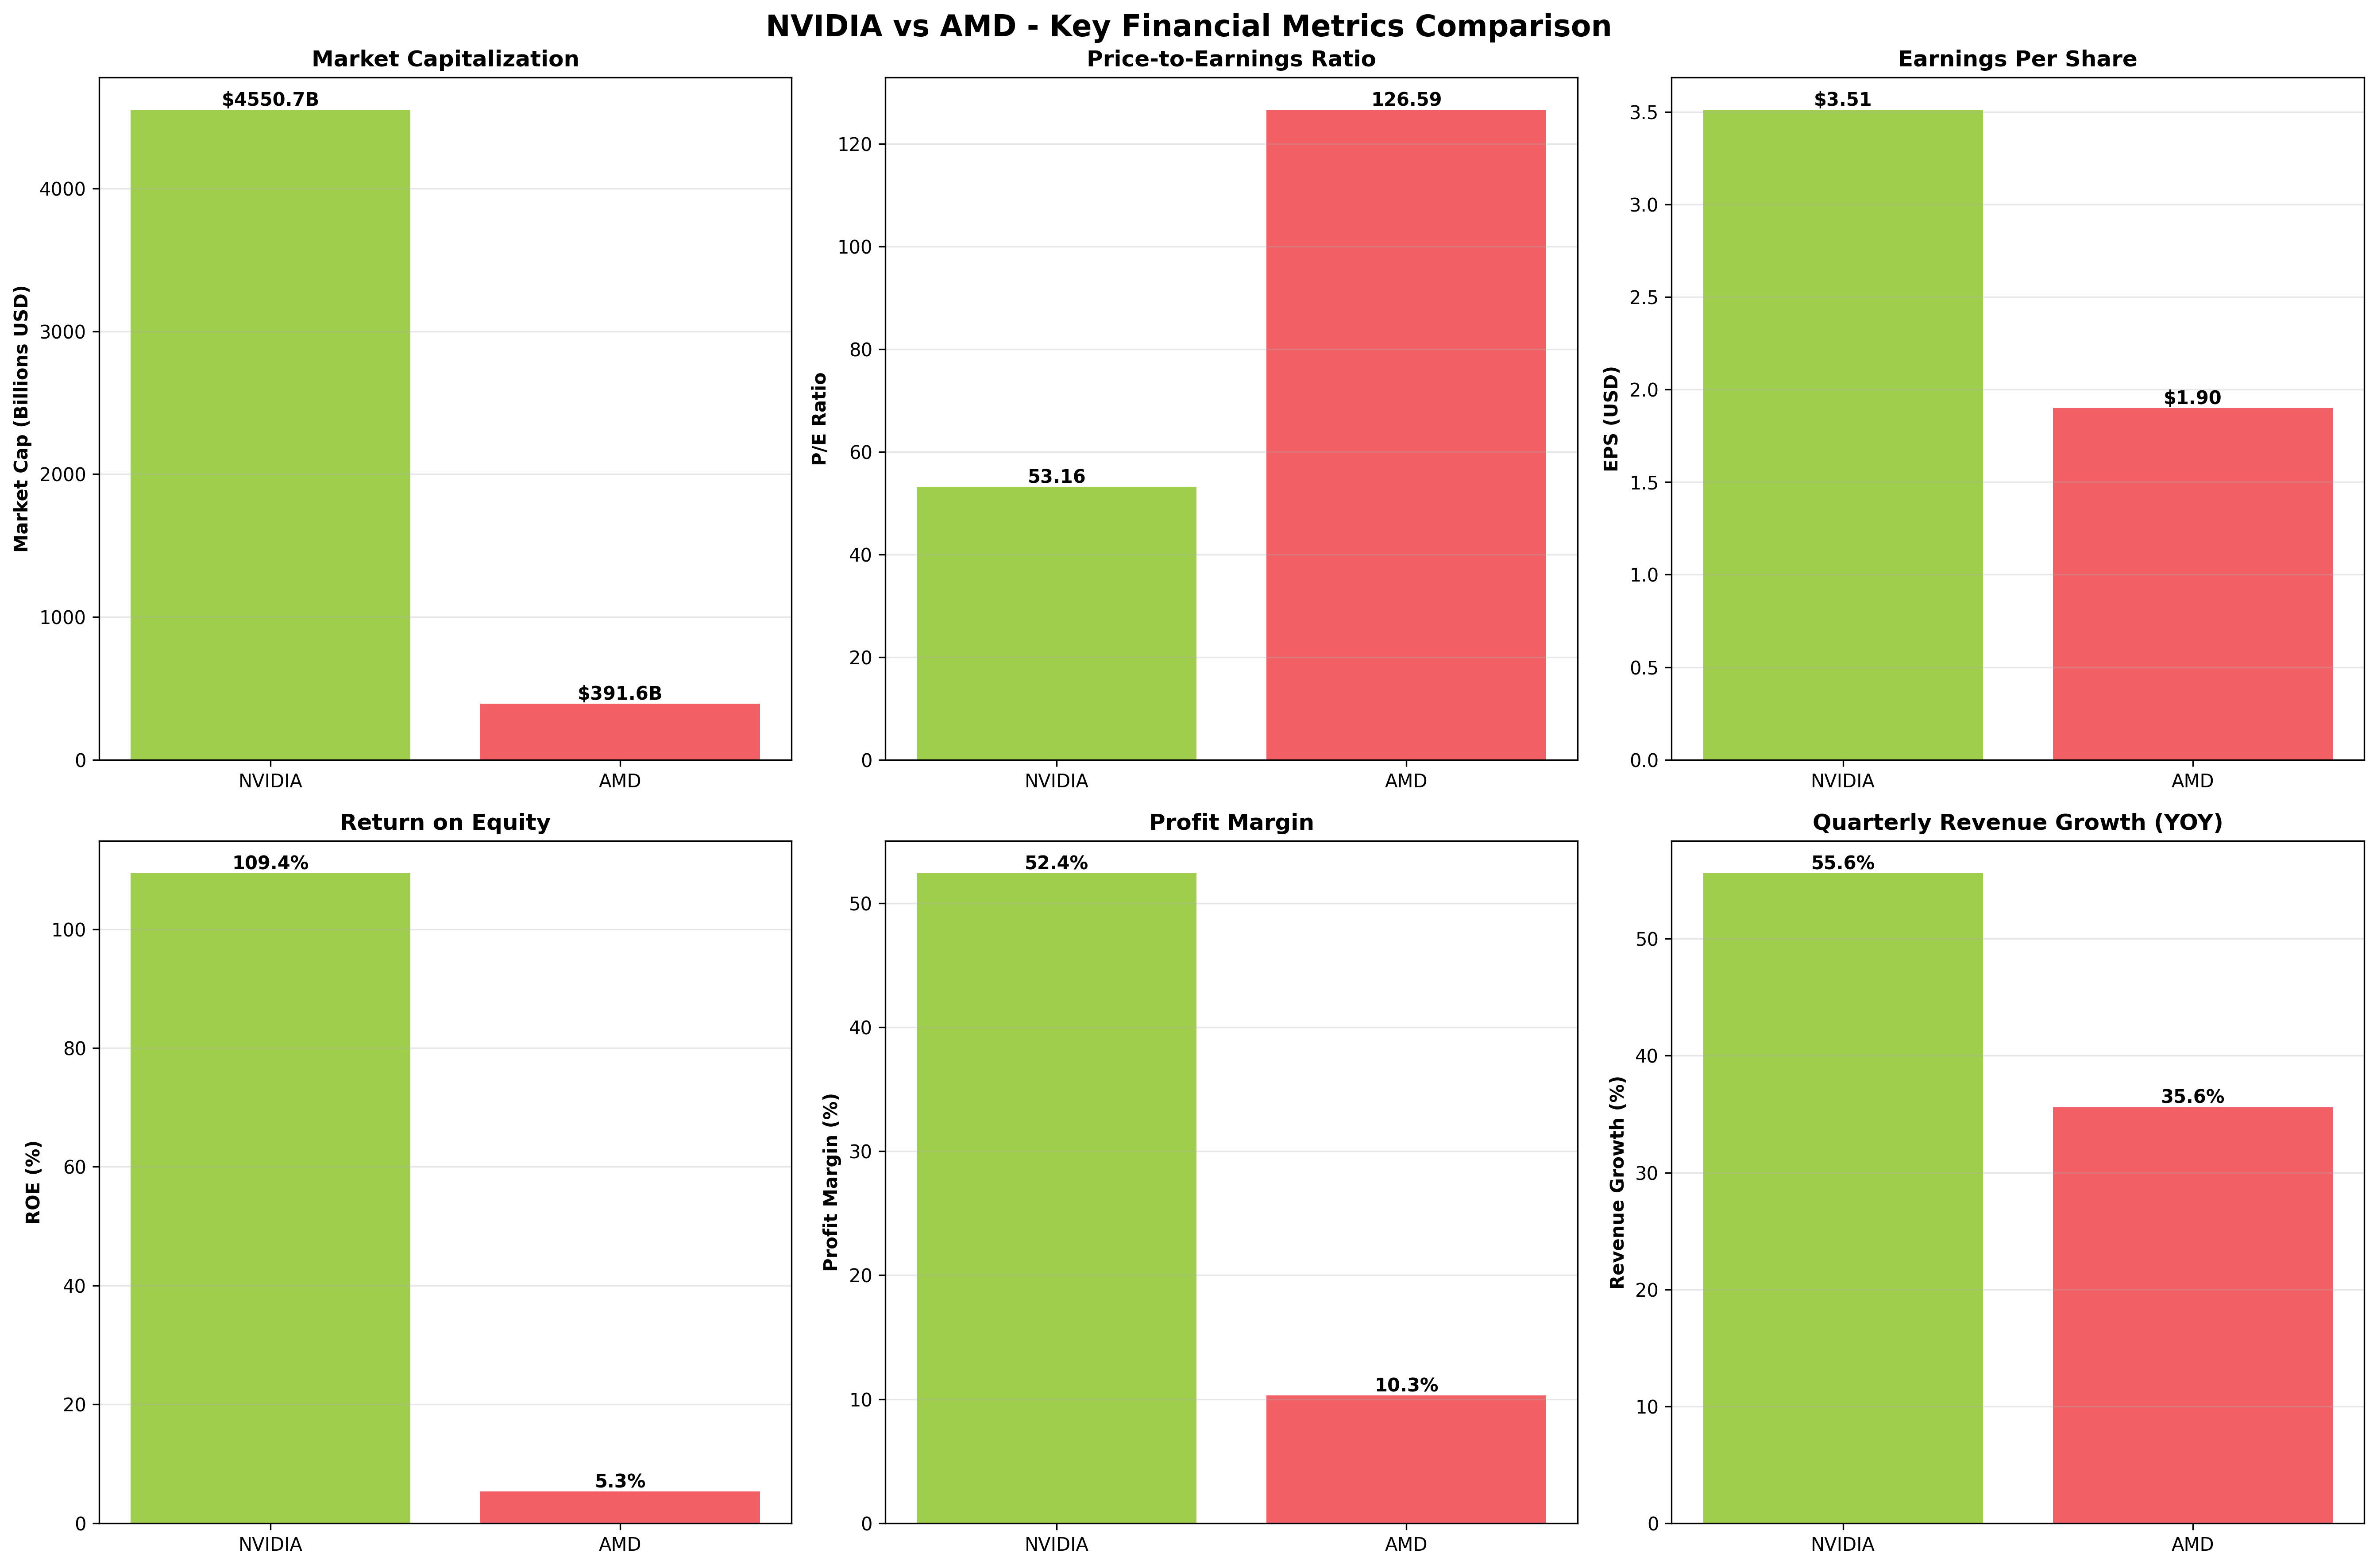

📊 results/revenue_earnings_comparison.png


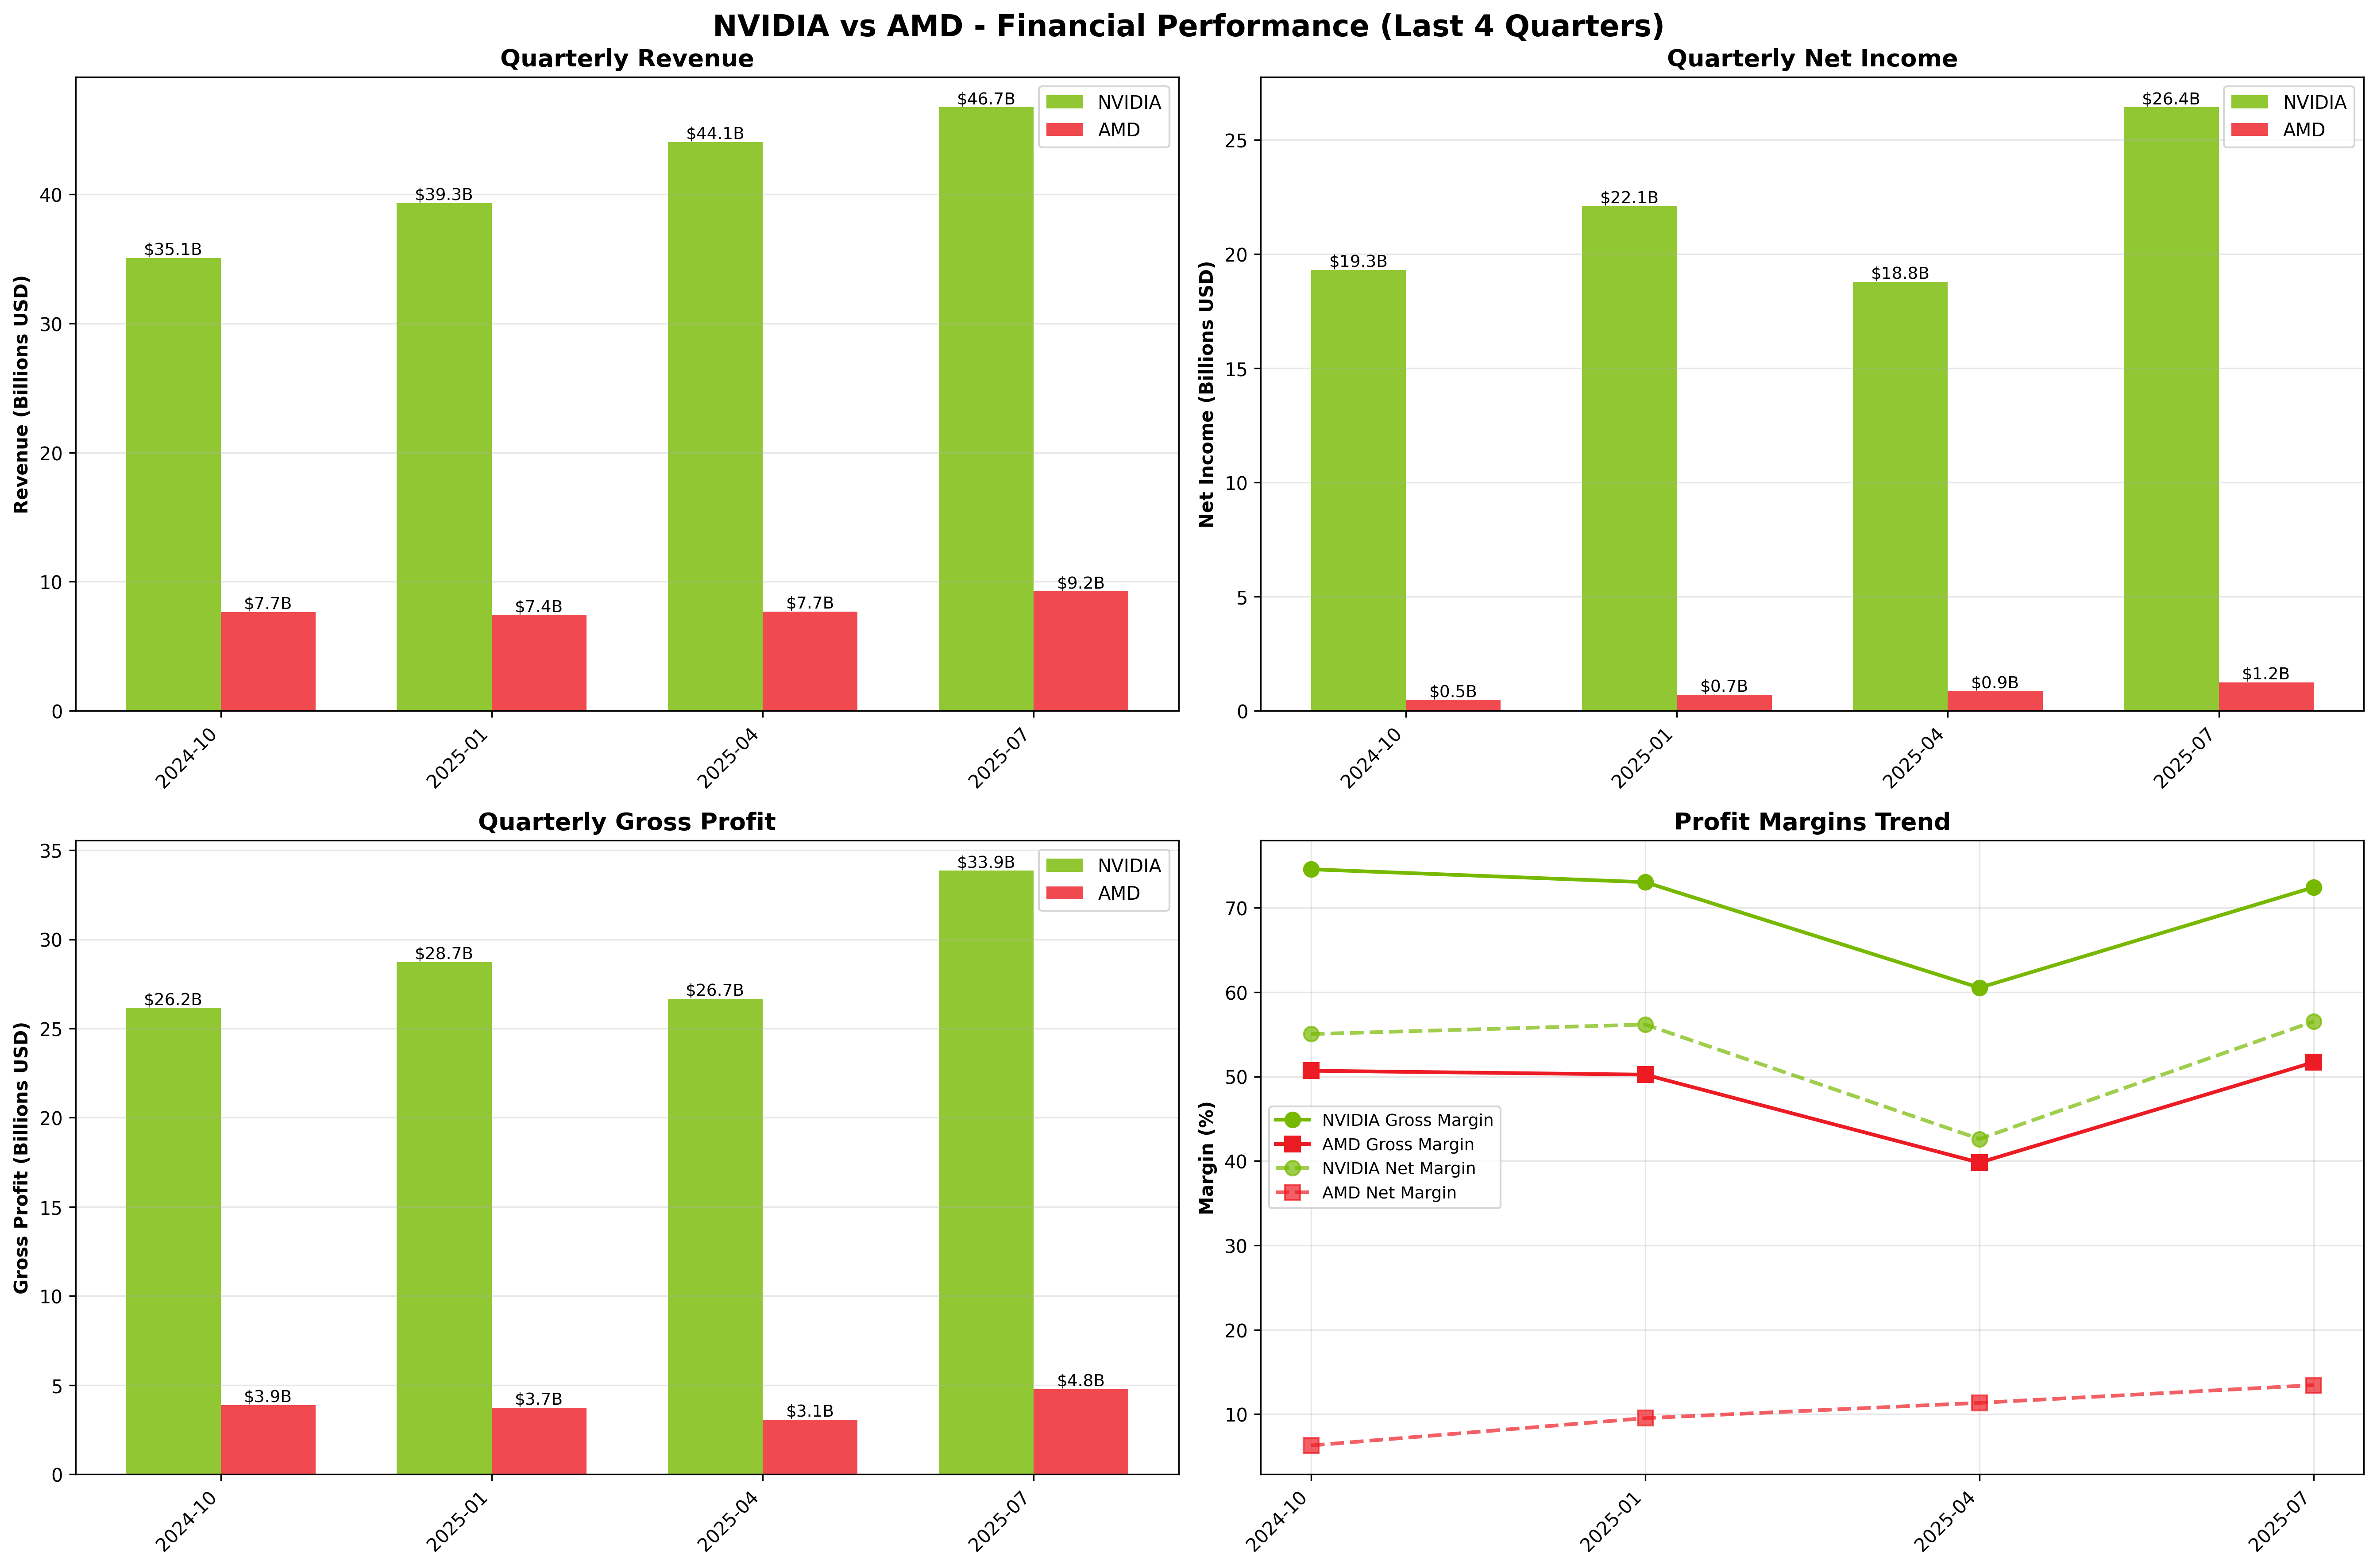

📊 results/stock_price_comparison.png


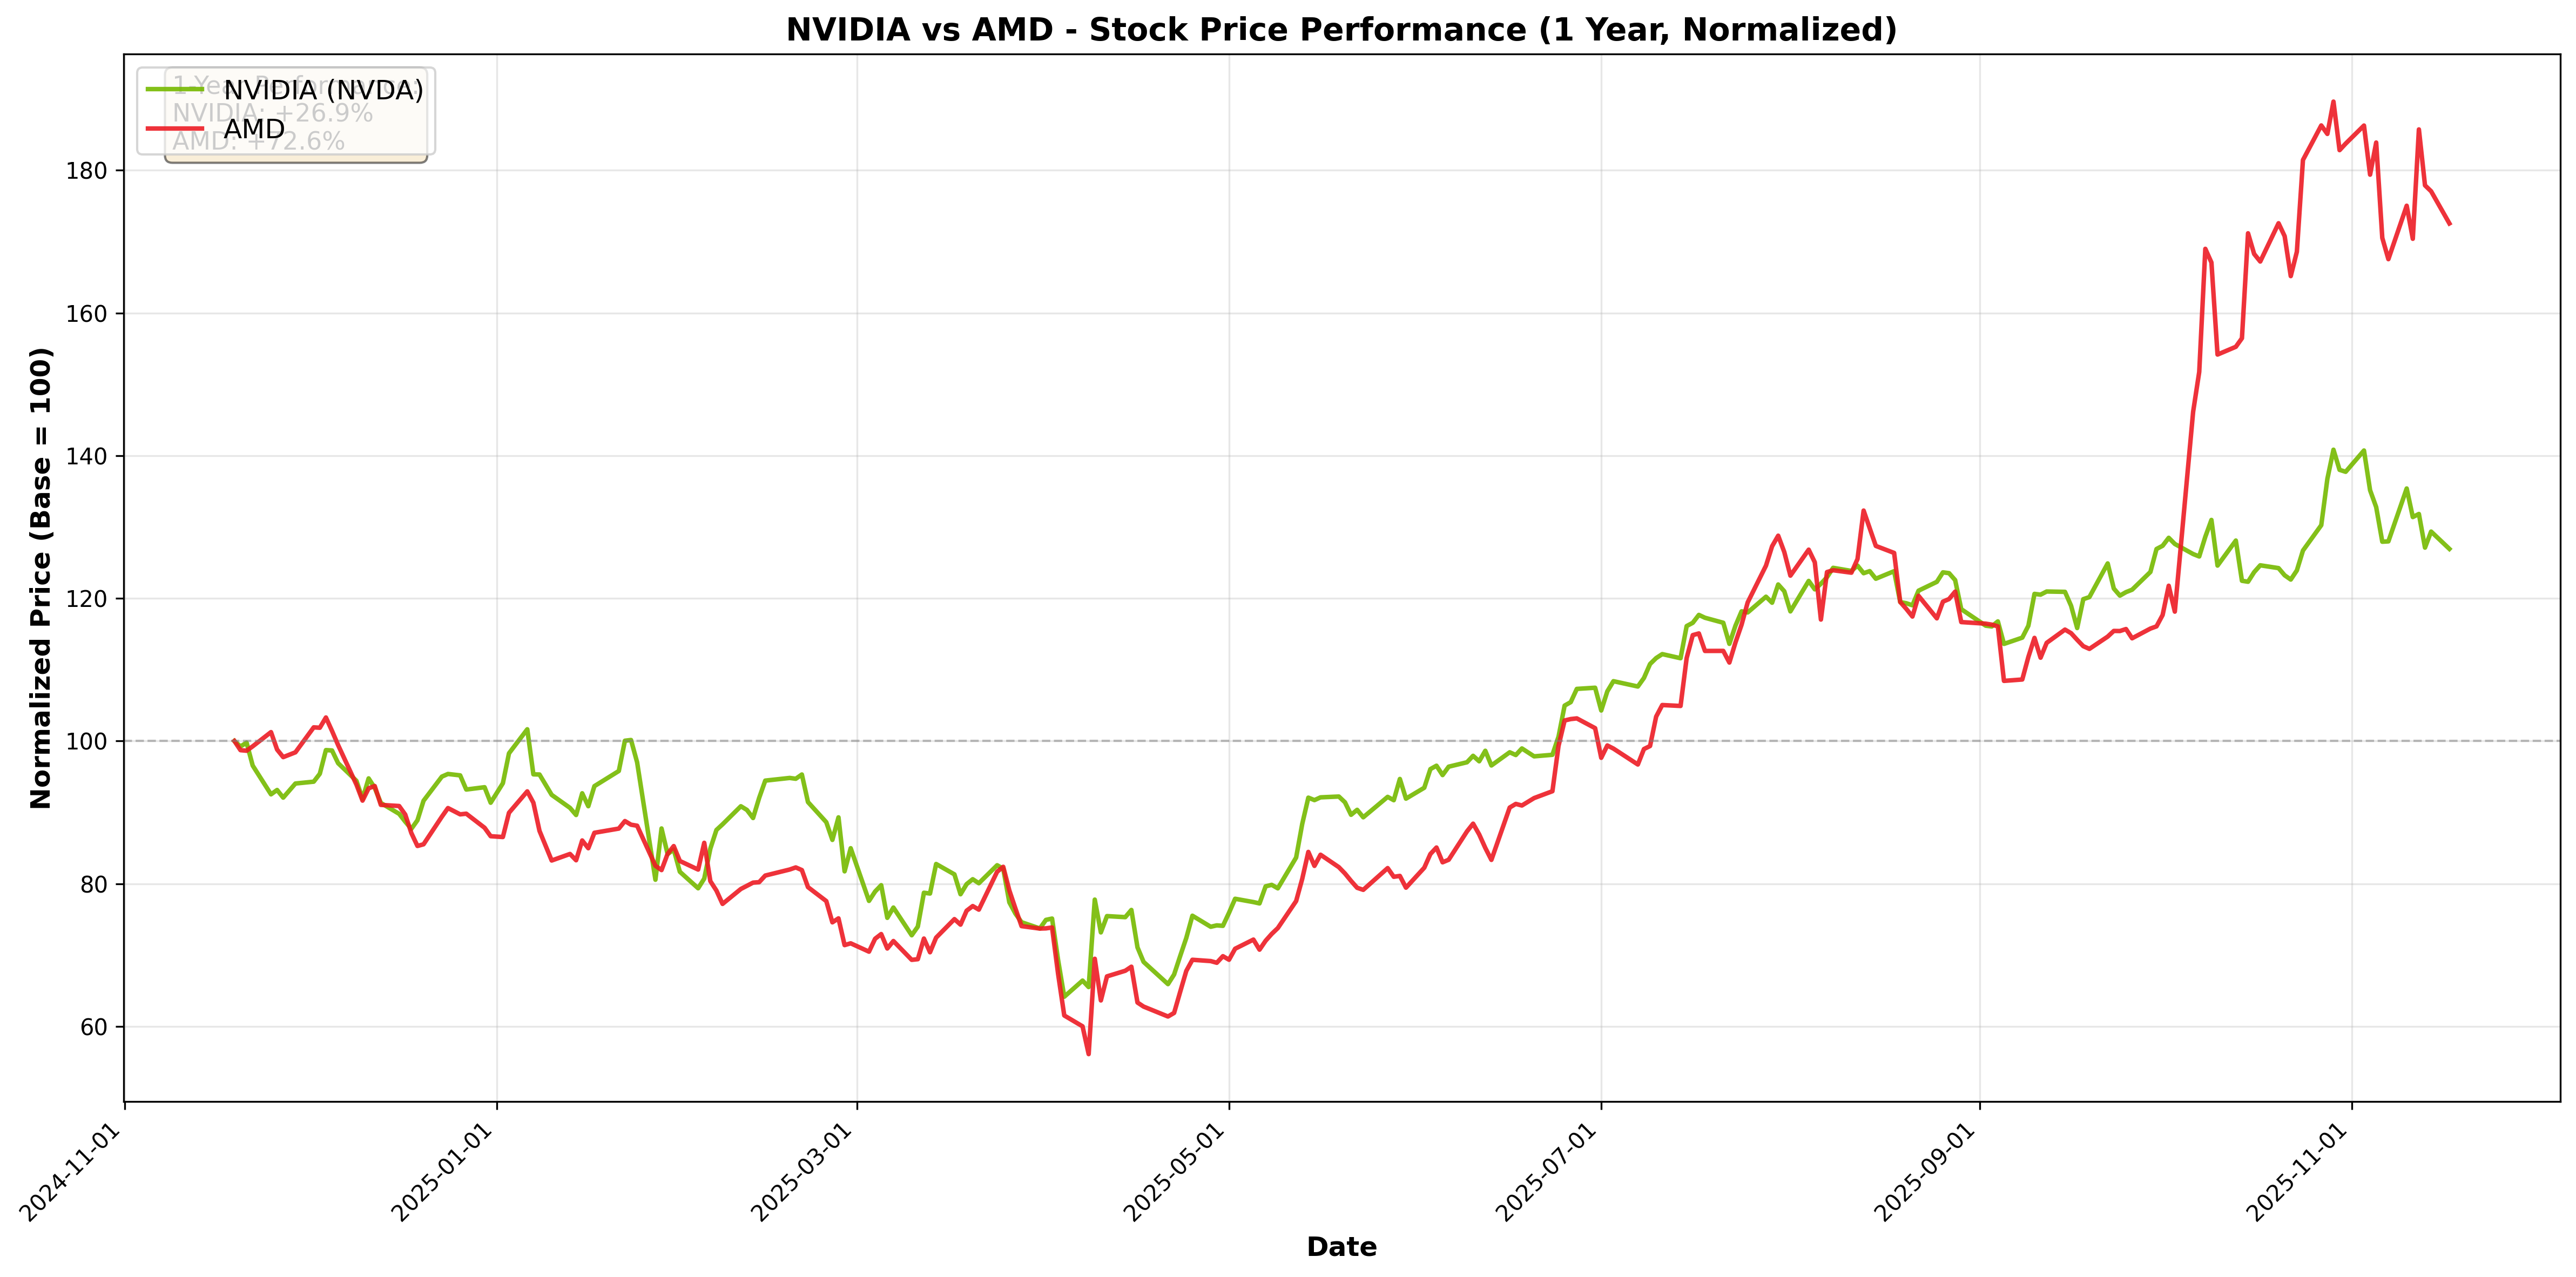

📊 results/trading_volume_comparison.png


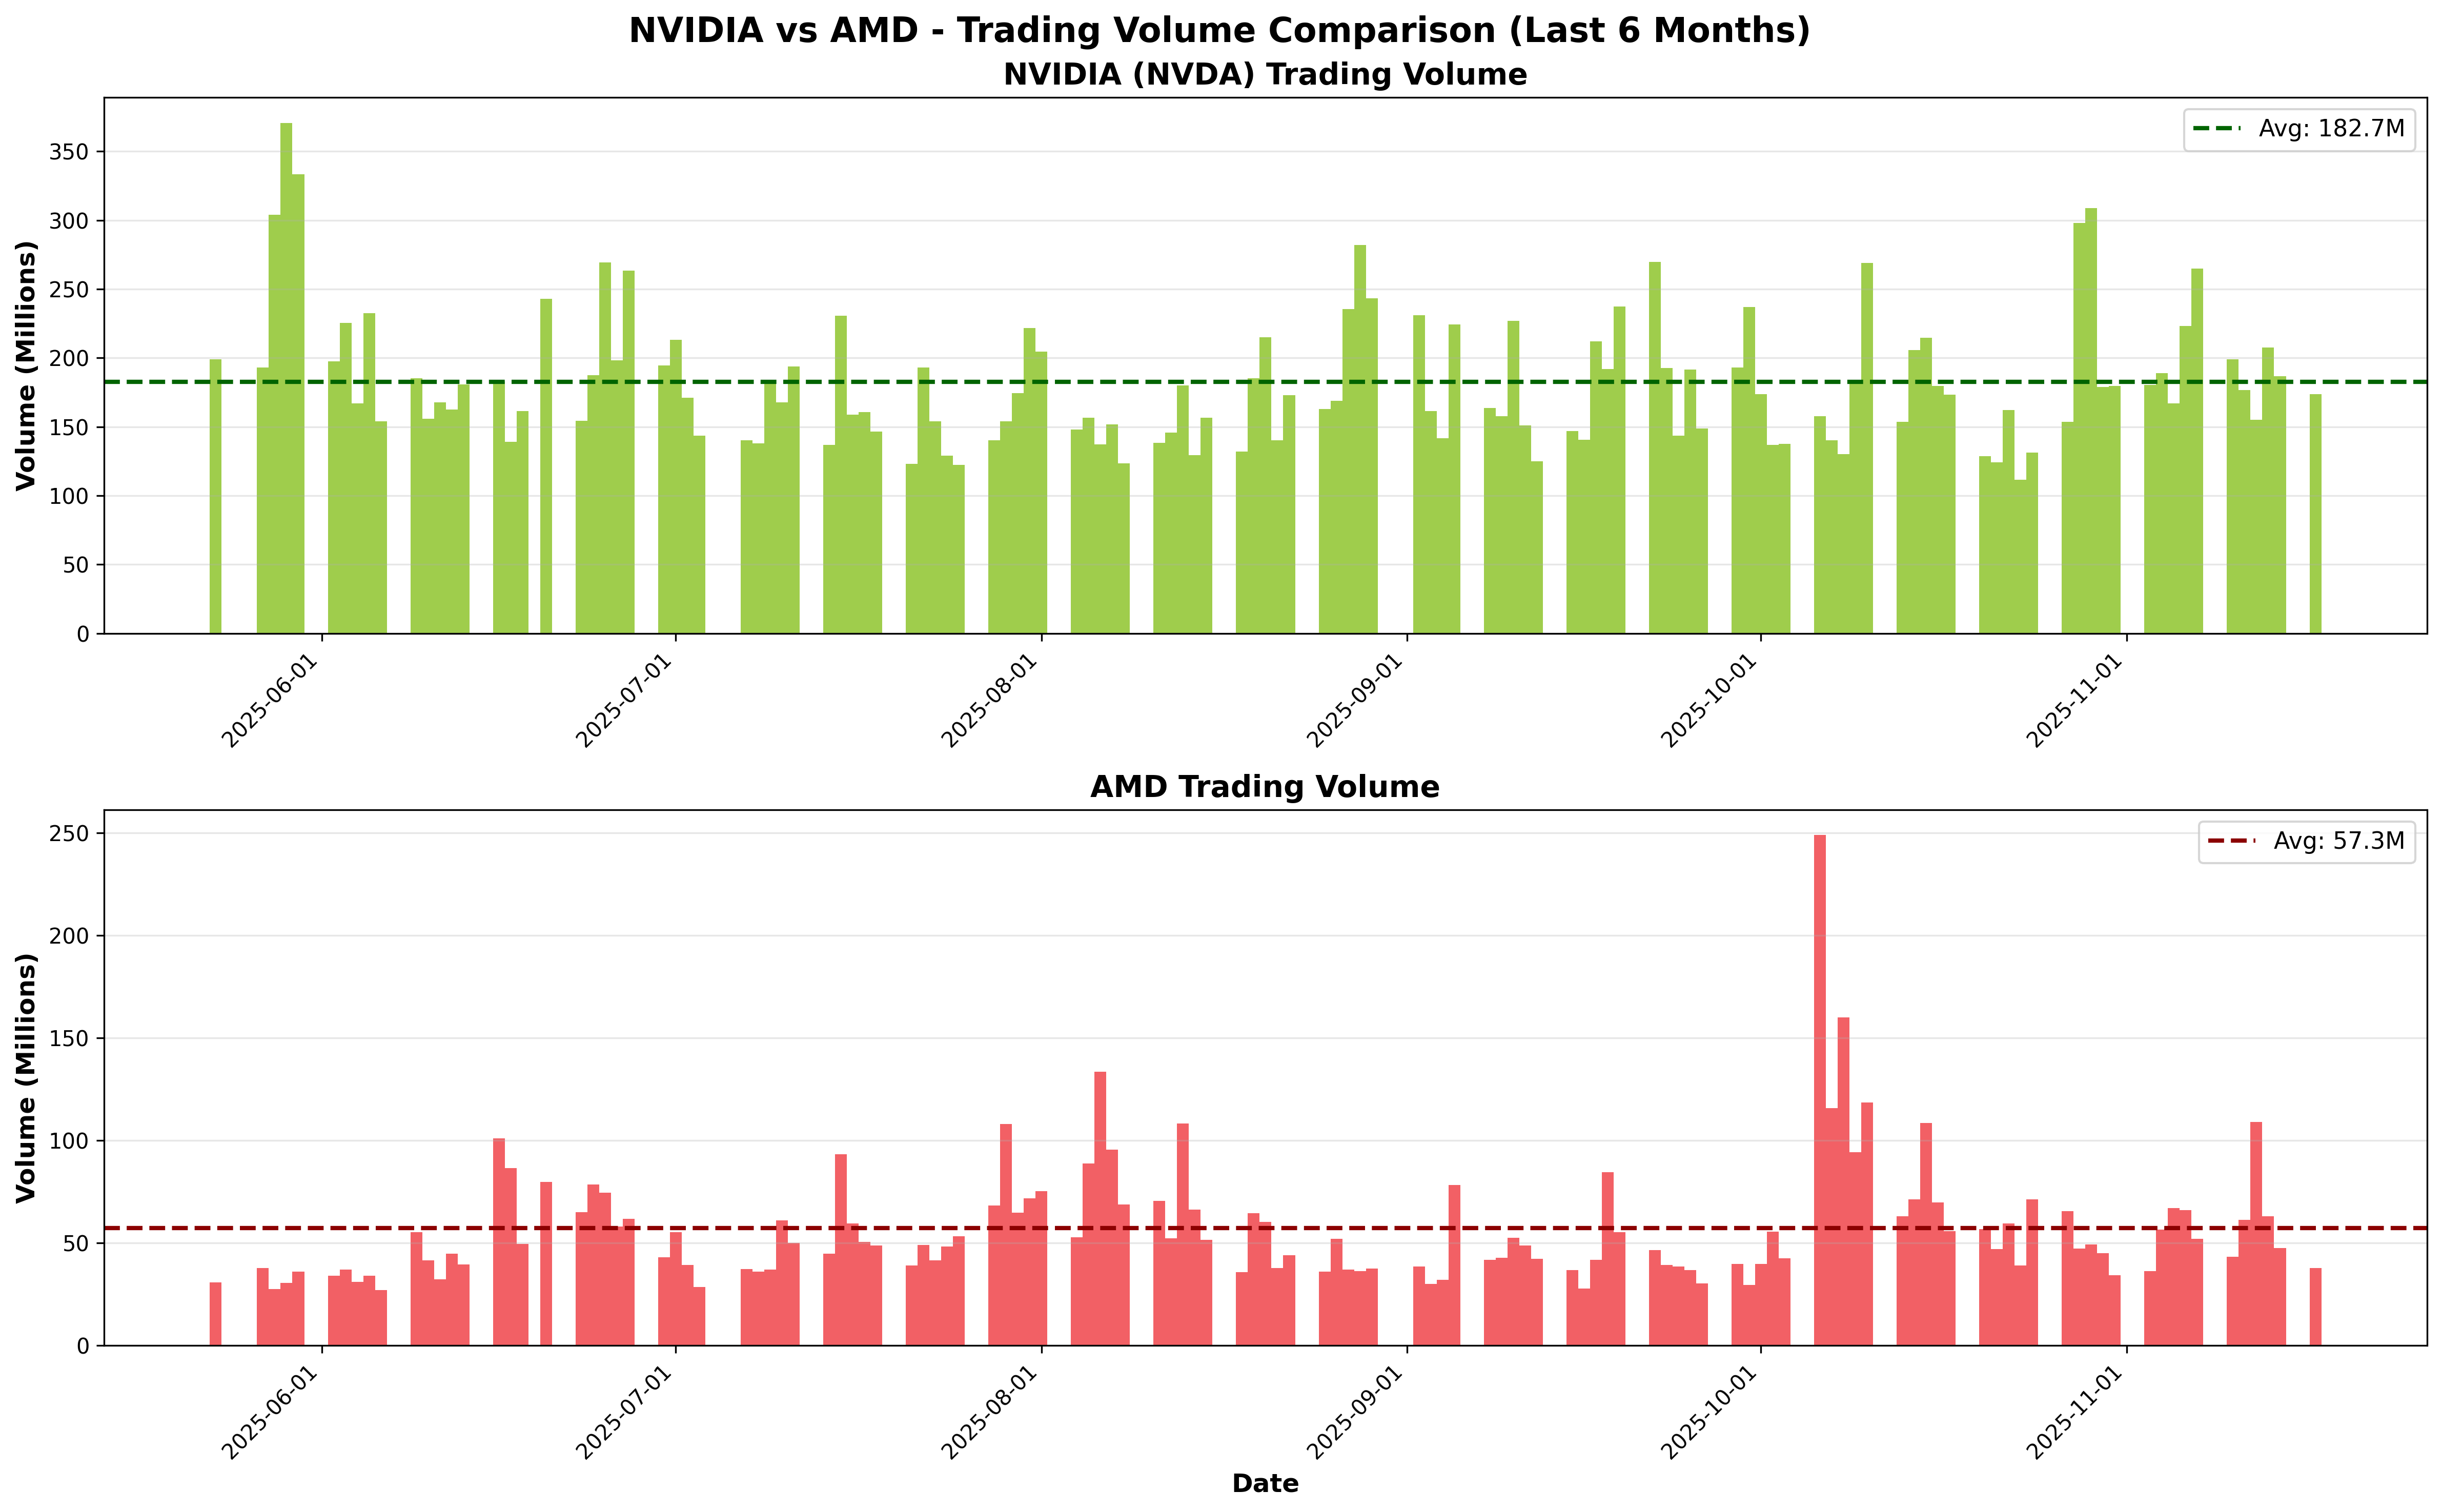


✅ Displayed 4 image(s)


In [9]:
# Display any images generated by the agent
display_sandbox_images(session.sandbox, "results")

In [10]:
# Display sandbox file tree After agent execution
print("=" * 50)
print("Sandbox File Tree (After)")
print("=" * 50)
print("./")
print_sandbox_tree(session.sandbox, path="code/")

Sandbox File Tree (After)
./
├── exec_0001.py
├── exec_0002.py
├── exec_0003.py
├── exec_0004.py
├── exec_0005.py
├── exec_0006.py
├── exec_0007.py
├── exec_0008.py
├── exec_0009.py
├── exec_0010.py
├── exec_0011.py
├── exec_0012.py
├── exec_0013.py
├── exec_0014.py
├── exec_0015.py
├── exec_0016.py
├── exec_0017.py
├── exec_0018.py
├── exec_0019.py
├── exec_0020.py
├── exec_0021.py
├── exec_0022.py
├── exec_0023.py
└── exec_0024.py


In [11]:
print_sandbox_tree(session.sandbox, path="results/")

├── NVIDIA_Comprehensive_Research_Report.md
├── README.md
├── amd_balance.json
├── amd_cashflow.json
├── amd_daily.json
├── amd_income.json
├── amd_overview.json
├── amd_quote.json
├── financial_metrics_comparison.png
├── nvda_balance.json
├── nvda_bbands.json
├── nvda_cashflow.json
├── nvda_daily.csv
├── nvda_daily.json
├── nvda_income.json
├── nvda_macd.csv
├── nvda_macd.json
├── nvda_overview.json
├── nvda_quote.csv
├── nvda_quote.json
├── nvda_research.json
├── nvda_rsi.csv
├── nvda_rsi.json
├── nvda_sma_200.json
├── nvda_sma_50.json
├── revenue_earnings_comparison.png
├── stock_price_comparison.png
├── task_request.md
└── trading_volume_comparison.png


In [13]:
# Cleanup session when done
await session.cleanup()

2025-11-18 15:54:25 [info     ] Cleaning up session            conversation_id=demo-notebook
2025-11-18 15:54:25 [info     ] Cleaning up sandbox            sandbox_id=0cf9988c-3bcc-4651-bbf6-0a857d29b371
2025-11-18 15:54:25 [info     ] Sandbox deleted                sandbox_id=0cf9988c-3bcc-4651-bbf6-0a857d29b371
2025-11-18 15:54:25 [info     ] Disconnecting from all MCP servers
2025-11-18 15:54:25 [info     ] Disconnecting from MCP server  server=tavily
2025-11-18 15:54:25 [info     ] Disconnecting from MCP server  server=alphavantage
2025-11-18 15:54:25 [info     ] Disconnecting from MCP server  server=tickertick
2025-11-18 15:54:25 [debug    ] Disconnected from MCP server   server=alphavantage
2025-11-18 15:54:25 [debug    ] Disconnected from MCP server   server=tavily
2025-11-18 15:54:25 [debug    ] Disconnected from MCP server   server=tickertick
2025-11-18 15:54:25 [info     ] Session cleaned up             conversation_id=demo-notebook
